In [3]:
import torch
import clip
from PIL import Image

# 1. Load the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 2. Load and preprocess your image
image = preprocess(Image.open(r"D:\college materials\3 semester 1\Deeplearing\section\pytorch\Sea Creatures project\samples\Clams.jpg")).unsqueeze(0).to(device)

# 3. Tokenize your text labels
text = clip.tokenize(["a fish", "Squid", "a clam"]).to(device)

# 4. Calculate probabilities
with torch.no_grad():
    logits_per_image, logits_per_text = model(image, text)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

print("Label probabilities:", probs)

Label probabilities: [[0.06256 0.705   0.2324 ]]



Evaluating with template: 'a photo of a {}'
Processing 20 images for class: Crab
Processing 20 images for class: Dolphin
Processing 20 images for class: Eel
Processing 20 images for class: Jelly Fish
Processing 20 images for class: Lobster
Processing 20 images for class: Octopus
Processing 20 images for class: Otter
Processing 20 images for class: Puffer
Processing 20 images for class: Sea Ray
Processing 20 images for class: Sea Urchin
Processing 20 images for class: Sea Horse
Processing 20 images for class: Seal
Processing 19 images for class: Shark
Processing 20 images for class: Shrimp
Processing 20 images for class: Squid
Processing 20 images for class: Starfish
Processing 20 images for class: Sea Turtle
Processing 20 images for class: Whale

Accuracy: 0.5181

Per-class metrics:
              precision    recall  f1-score   support

       Clams       0.00      0.00      0.00         0
        Crab       0.43      0.95      0.59        20
     Dolphin       1.00      0.75      0.8

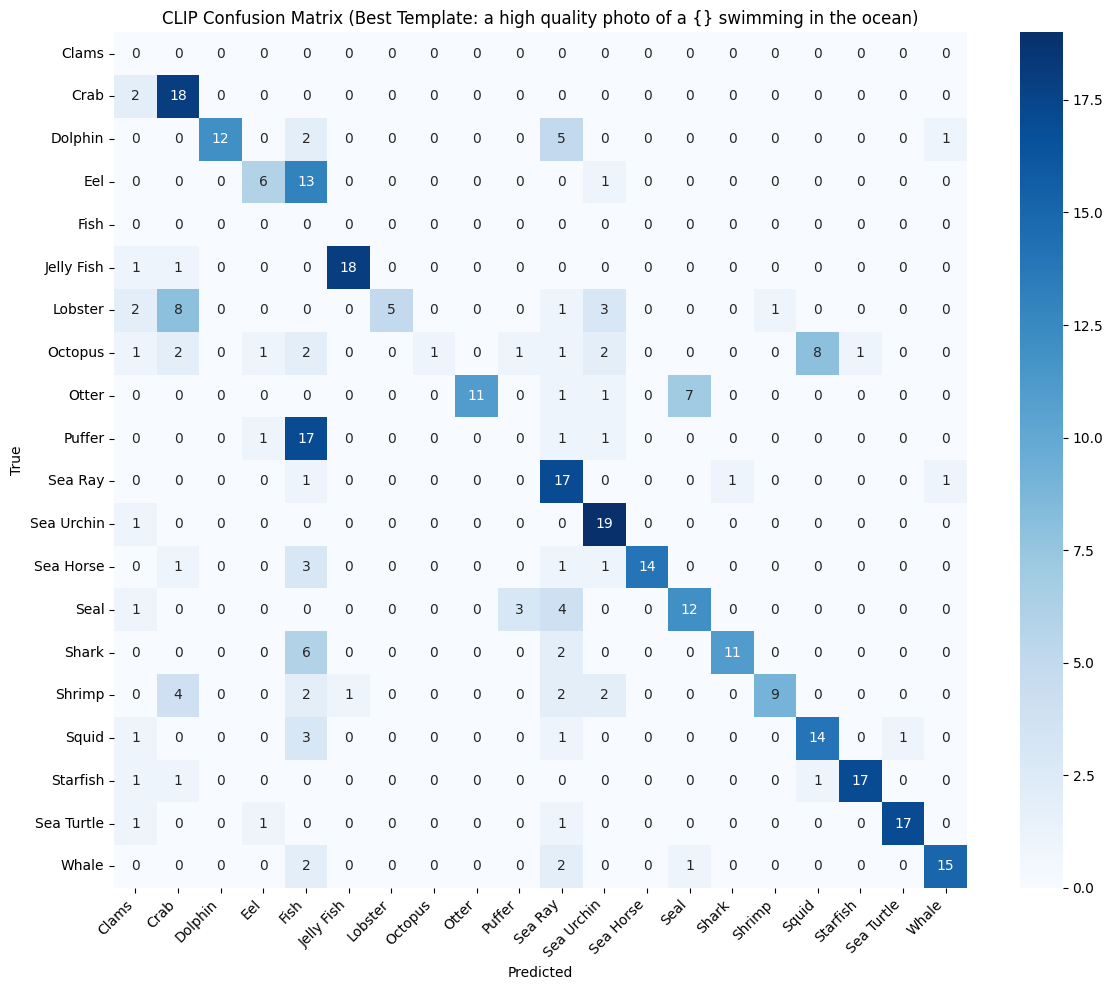

In [ ]:
import torch
import clip
from PIL import Image
import os
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup CLIP
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 2. Your 20 sea creature classes (customize these)
sea_creature_classes = ['Clam',  'Crab', 'Dolphin', 'Eel', 'Jelly Fish',
                      'Lobster', 'Octopus', 'Otter',  'Puffer',
                      'Sea Ray', 'Sea Urchin', 'Sea Horse', 'Seal', 'Shark', 'Shrimp',
                      'Squid', 'Starfish', 'Sea Turtle', 'Whale'] 

# 3. Create text prompts - CRITICAL STEP!
# Try these different prompt templates:
prompt_templates = [
    "a photo of a {}",
    "an underwater photo of a {}",
    "a marine animal called {}",
    "a close up photo of a {}",
    "a high quality photo of a {} swimming in the ocean"
]

# 4. Function to test different prompts
def evaluate_with_prompt(template, data_dir):
    """Evaluate CLIP using a specific prompt template"""
    
    print(f"\n{'='*60}")
    print(f"Evaluating with template: '{template}'")
    print('='*60)
    
    # Prepare text inputs
    text_descriptions = [template.format(cls) for cls in sea_creature_classes]
    text_inputs = clip.tokenize(text_descriptions).to(device)
    
    true_labels = []
    predicted_labels = []
    all_probabilities = []
    
    # Iterate through each class directory
    for class_idx, class_name in enumerate(sea_creature_classes):
        class_dir = os.path.join(data_dir, class_name)
        
        if not os.path.isdir(class_dir):
            print(f"Warning: Directory not found for class '{class_name}'")
            continue
        
        # Process images in this class directory
        image_files = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
        
        print(f"Processing {len(image_files)} images for class: {class_name}")
        
        for img_file in image_files[:100]:  # Limit to 100 images per class for speed
            img_path = os.path.join(class_dir, img_file)
            
            try:
                # Load and preprocess image
                image = Image.open(img_path).convert("RGB")
                image_input = preprocess(image).unsqueeze(0).to(device)
                
                # Get CLIP predictions
                with torch.no_grad():
                    image_features = model.encode_image(image_input)
                    text_features = model.encode_text(text_inputs)
                    logits = (image_features @ text_features.T)
                    probs = logits.softmax(dim=-1).cpu().numpy()[0]
                
                # Get prediction
                pred_idx = np.argmax(probs)
                predicted_class = sea_creature_classes[pred_idx]
                
                # Store results
                true_labels.append(class_name)
                predicted_labels.append(predicted_class)
                all_probabilities.append(probs)
                
            except Exception as e:
                print(f"  Error processing {img_file}: {e}")
                continue
    
    return true_labels, predicted_labels, all_probabilities

# 5. Main evaluation
def main():
    data_dir = r"D:\Data Sets\see creatures images\test"  # UPDATE THIS PATH
    
    if not os.path.exists(data_dir):
        print(f"Error: Directory not found: {data_dir}")
        return
    
    # Test each prompt template
    best_accuracy = 0
    best_results = None
    best_template = ""
    
    for template in prompt_templates:
        true_labels, pred_labels, probs = evaluate_with_prompt(template, data_dir)
        
        if len(true_labels) == 0:
            print("No images were processed. Check your data directory path.")
            continue
        
        # Calculate metrics
        accuracy = accuracy_score(true_labels, pred_labels)
        print(f"\nAccuracy: {accuracy:.4f}")
        print("\nPer-class metrics:")
        print(classification_report(true_labels, pred_labels, 
                                   target_names=sea_creature_classes, zero_division=0))
        
        # Track best performing template
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_results = (true_labels, pred_labels, probs)
            best_template = template
    
    # 6. Visualize best results
    if best_results:
        print(f"\n{'='*60}")
        print(f"BEST TEMPLATE: '{best_template}' with accuracy: {best_accuracy:.4f}")
        print('='*60)
        
        true_labels, pred_labels, probs = best_results
        
        # Create confusion matrix
        cm = confusion_matrix(true_labels, pred_labels, labels=sea_creature_classes)
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=sea_creature_classes,
                   yticklabels=sea_creature_classes)
        plt.title(f'CLIP Confusion Matrix (Best Template: {best_template})')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('clip_confusion_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Save detailed results
        with open('clip_evaluation_results.txt', 'w') as f:
            f.write(f"CLIP Evaluation Results\n")
            f.write(f"Dataset: {data_dir}\n")
            f.write(f"Best prompt template: {best_template}\n")
            f.write(f"Overall accuracy: {best_accuracy:.4f}\n\n")
            
            # Per-class accuracy
            f.write("Per-class accuracy:\n")
            for cls in sea_creature_classes:
                cls_indices = [i for i, label in enumerate(true_labels) if label == cls]
                if cls_indices:
                    cls_correct = sum(1 for i in cls_indices if pred_labels[i] == cls)
                    cls_acc = cls_correct / len(cls_indices)
                    f.write(f"  {cls}: {cls_acc:.4f} ({cls_correct}/{len(cls_indices)})\n")

if __name__ == "__main__":
    main()

CLIP EVALUATION - SEA CREATURE CLASSIFICATION

1. STANDARD PROMPT EVALUATION
----------------------------------------

Trying template: 'a photo of {}'
  Accuracy: 0.8628

Trying template: 'an underwater photograph of {}'
  Accuracy: 0.8654

Trying template: 'a marine biology image of {}'
  Accuracy: 0.9024

Trying template: '{} in its natural ocean habitat'
  Accuracy: 0.8892

Trying template: 'wildlife photography of {}'
  Accuracy: 0.8681

✓ Best standard template: 'a marine biology image of {}' (Accuracy: 0.9024)


2. ENSEMBLE EVALUATION
----------------------------------------

ENSEMBLE EVALUATION - Combining multiple prompts
Processing 20 images for: Clam
  Image: Clam_1077.jpg
  True: Clam, Predicted: Clam
  Top 3: [('Clam', 0.05721282958984375), ('Starfish', 0.055263519287109375), ('Eel', 0.0543060302734375)]
  Image: Clam_1163.jpeg
  True: Clam, Predicted: Clam
  Top 3: [('Clam', 0.055469512939453125), ('Starfish', 0.0544891357421875), ('Sea Urchin', 0.054447174072265625)]
  I

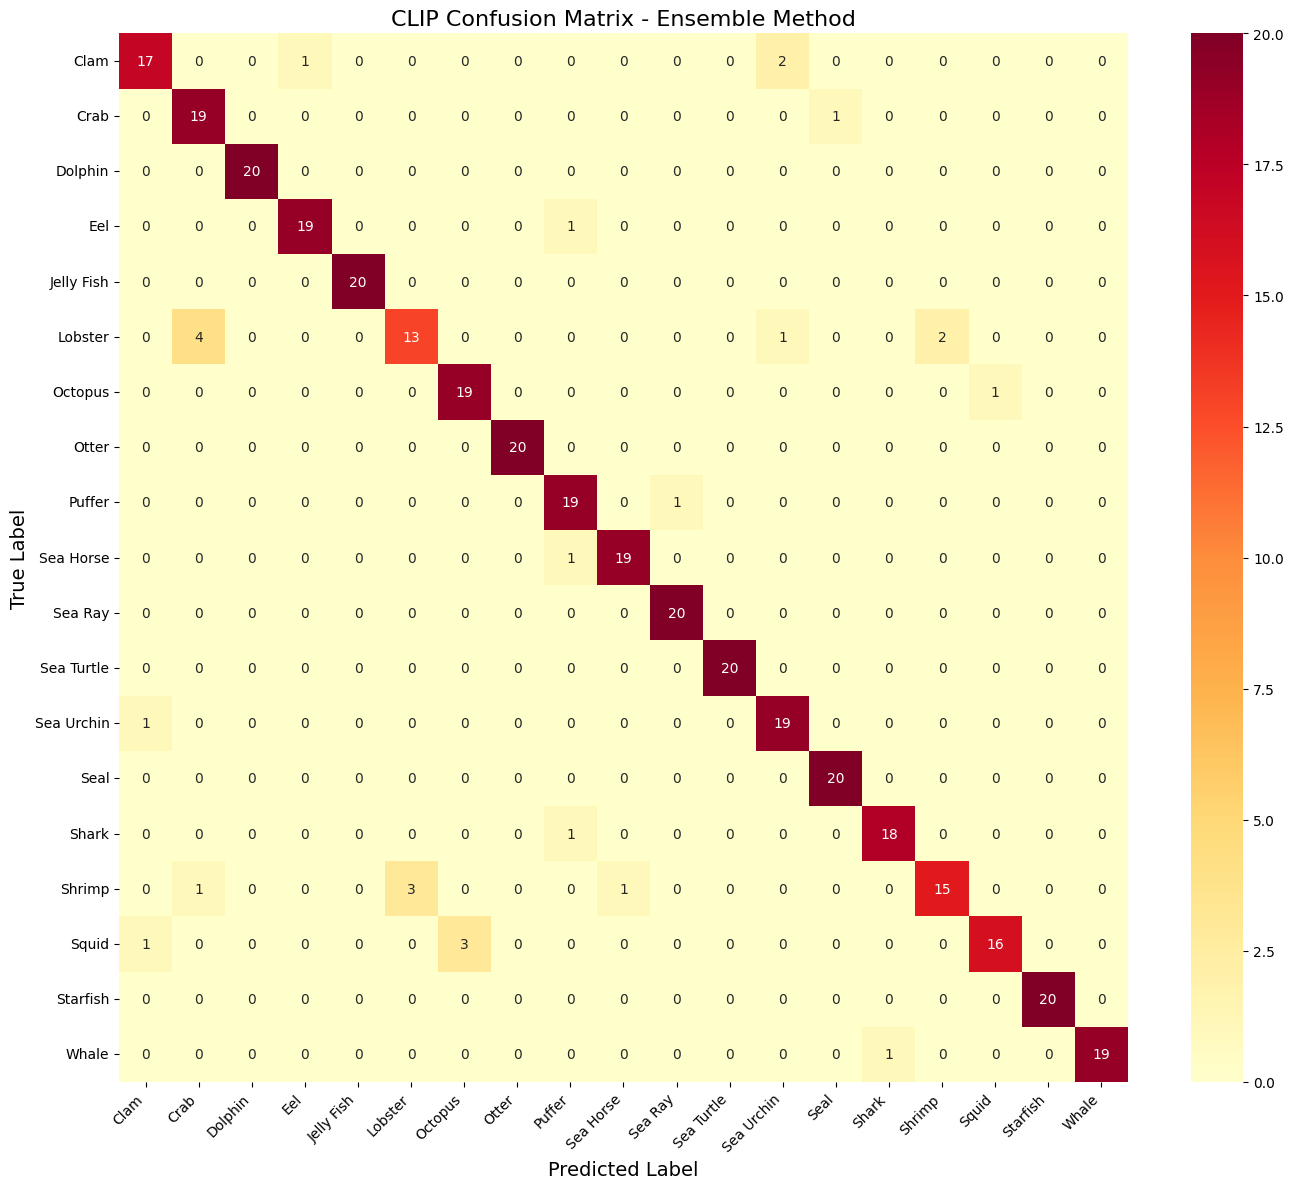

In [6]:
import torch
import clip
from PIL import Image
import os
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup CLIP - Try a larger model
device = "cuda" if torch.cuda.is_available() else "cpu"
# Try ViT-L/14 for better accuracy (slower but more accurate)
model, preprocess = clip.load("ViT-L/14", device=device)

# 2. Enhanced class names - fix plurals and clarity
sea_creature_classes = [
    "Clam",
    "Crab",
    "Dolphin",
    "Eel",
    "Jelly Fish",
    "Lobster",
    "Octopus",
    "Otter",
    "Puffer",
    "Sea Horse",
    "Sea Ray",
    "Sea Turtle",
    "Sea Urchin",
    "Seal",
    "Shark",
    "Shrimp",
    "Squid",
    "Starfish",
    "Whale"
]
# 3. DRAMATICALLY IMPROVED PROMPT TEMPLATES
prompt_templates = [
    # Standard prompts
    "a photo of {}",
    "an underwater photograph of {}",
    "a marine biology image of {}",
    
    # Scientific/descriptive prompts
    "{} in its natural ocean habitat",
    "wildlife photography of {}",
    "zoology specimen: {}",
    
    # Multiple variations for each class
    "image of {} swimming in clear blue water",
    "close-up portrait of {}",
    "high resolution image of {}",
    
    # Negative prompts (what it's NOT)
    "photo of {}, not a drawing",
    "real photograph of {}",
    
    # Habitat-specific
    "ocean creature: {}",
    "sea animal: {}",
    "marine species called {}"
]

# 4. ENSEMBLE EVALUATION - Combine multiple prompts
def evaluate_ensemble(data_dir, top_k=3):
    """Use ensemble of multiple prompts for better accuracy"""
    
    print(f"\n{'='*70}")
    print("ENSEMBLE EVALUATION - Combining multiple prompts")
    print('='*70)
    
    all_true_labels = []
    all_predicted_labels = []
    
    # Process each class
    for class_idx, class_name in enumerate(sea_creature_classes):
        class_dir = os.path.join(data_dir, class_name)
        
        if not os.path.isdir(class_dir):
            print(f"Warning: Directory not found for class '{class_name}'")
            continue
        
        # Get images
        image_files = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        print(f"Processing {min(len(image_files), 50)} images for: {class_name}")
        
        for img_file in image_files[:50]:  # Process 50 per class
            img_path = os.path.join(class_dir, img_file)
            
            try:
                # Load image
                image = Image.open(img_path).convert("RGB")
                image_input = preprocess(image).unsqueeze(0).to(device)
                
                # Get image embedding once
                with torch.no_grad():
                    image_features = model.encode_image(image_input)
                    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                
                # Try different prompts and average predictions
                class_probs = np.zeros(len(sea_creature_classes))
                
                for template in prompt_templates[:8]:  # Use first 8 templates for speed
                    # Prepare text for this template
                    text_descriptions = [template.format(cls) for cls in sea_creature_classes]
                    text_inputs = clip.tokenize(text_descriptions).to(device)
                    
                    # Get text embeddings
                    with torch.no_grad():
                        text_features = model.encode_text(text_inputs)
                        text_features = text_features / text_features.norm(dim=-1, keepdim=True)
                    
                    # Calculate similarity
                    similarity = (image_features @ text_features.T).cpu().numpy()[0]
                    probs = np.exp(similarity) / np.sum(np.exp(similarity))  # Softmax
                    
                    # Accumulate probabilities
                    class_probs += probs
                
                # Average predictions from all templates
                class_probs = class_probs / len(prompt_templates[:8])
                
                # Get final prediction (highest probability)
                pred_idx = np.argmax(class_probs)
                predicted_class = sea_creature_classes[pred_idx]
                
                # Also get top-3 predictions for analysis
                top_3_indices = np.argsort(class_probs)[-3:][::-1]
                top_3_classes = [sea_creature_classes[i] for i in top_3_indices]
                top_3_probs = [class_probs[i] for i in top_3_indices]
                
                # Store results
                all_true_labels.append(class_name)
                all_predicted_labels.append(predicted_class)
                
                # Debug: Show top predictions for first few images
                if len(all_true_labels) <= 5:
                    print(f"  Image: {img_file}")
                    print(f"  True: {class_name}, Predicted: {predicted_class}")
                    print(f"  Top 3: {list(zip(top_3_classes, top_3_probs))}")
                    
            except Exception as e:
                continue
    
    return all_true_labels, all_predicted_labels

# 5. FEW-SHOT REFERENCE METHOD (More accurate)
def evaluate_with_reference(data_dir, shots_per_class=5):
    """Use a few reference images per class for better matching"""
    
    print(f"\n{'='*70}")
    print(f"FEW-SHOT EVALUATION ({shots_per_class} shots per class)")
    print('='*70)
    
    # First, collect reference embeddings for each class
    reference_embeddings = {}
    
    for class_name in sea_creature_classes:
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        
        image_files = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        class_embeddings = []
        for img_file in image_files[:shots_per_class]:
            try:
                image = Image.open(os.path.join(class_dir, img_file)).convert("RGB")
                image_input = preprocess(image).unsqueeze(0).to(device)
                
                with torch.no_grad():
                    embedding = model.encode_image(image_input)
                    embedding = embedding / embedding.norm(dim=-1, keepdim=True)
                    class_embeddings.append(embedding.cpu().numpy())
            except:
                continue
        
        if class_embeddings:
            reference_embeddings[class_name] = np.mean(class_embeddings, axis=0)
    
    # Now evaluate all images
    all_true_labels = []
    all_predicted_labels = []
    
    for class_name in sea_creature_classes:
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        
        image_files = [f for f in os.listdir(class_dir) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        for img_file in image_files[shots_per_class:shots_per_class+50]:  # Test on different images
            try:
                image = Image.open(os.path.join(class_dir, img_file)).convert("RGB")
                image_input = preprocess(image).unsqueeze(0).to(device)
                
                with torch.no_grad():
                    test_embedding = model.encode_image(image_input)
                    test_embedding = test_embedding / test_embedding.norm(dim=-1, keepdim=True)
                    test_embedding = test_embedding.cpu().numpy()
                
                # Compare to all reference embeddings
                best_similarity = -1
                best_class = None
                
                for ref_class, ref_embedding in reference_embeddings.items():
                    similarity = np.dot(test_embedding, ref_embedding.T)
                    if similarity > best_similarity:
                        best_similarity = similarity
                        best_class = ref_class
                
                all_true_labels.append(class_name)
                all_predicted_labels.append(best_class)
                
            except:
                continue
    
    return all_true_labels, all_predicted_labels

# 6. MAIN EVALUATION WITH MULTIPLE METHODS
def main():
    data_dir = r"D:\Data Sets\see creatures images\test"
    
    if not os.path.exists(data_dir):
        print(f"Error: Directory not found: {data_dir}")
        return
    
    print("=" * 70)
    print("CLIP EVALUATION - SEA CREATURE CLASSIFICATION")
    print("=" * 70)
    
    # Method 1: Standard prompt-based evaluation
    print("\n1. STANDARD PROMPT EVALUATION")
    print("-" * 40)
    
    best_accuracy = 0
    best_template = ""
    
    # Test a subset of templates for speed
    for template in prompt_templates[:5]:
        print(f"\nTrying template: '{template}'")
        
        # Prepare text
        text_descriptions = [template.format(cls) for cls in sea_creature_classes]
        text_inputs = clip.tokenize(text_descriptions).to(device)
        
        true_labels = []
        predicted_labels = []
        
        # Quick evaluation with 20 images per class
        for class_name in sea_creature_classes:
            class_dir = os.path.join(data_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            
            images = [f for f in os.listdir(class_dir) 
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:20]
            
            for img_file in images:
                try:
                    image = Image.open(os.path.join(class_dir, img_file)).convert("RGB")
                    image_input = preprocess(image).unsqueeze(0).to(device)
                    
                    with torch.no_grad():
                        image_features = model.encode_image(image_input)
                        text_features = model.encode_text(text_inputs)
                        similarity = (image_features @ text_features.T).softmax(dim=-1)
                        pred_idx = similarity.argmax().item()
                    
                    true_labels.append(class_name)
                    predicted_labels.append(sea_creature_classes[pred_idx])
                except:
                    continue
        
        if true_labels:
            acc = accuracy_score(true_labels, predicted_labels)
            print(f"  Accuracy: {acc:.4f}")
            
            if acc > best_accuracy:
                best_accuracy = acc
                best_template = template
    
    print(f"\n✓ Best standard template: '{best_template}' (Accuracy: {best_accuracy:.4f})")
    
    # Method 2: Ensemble evaluation
    print("\n\n2. ENSEMBLE EVALUATION")
    print("-" * 40)
    ensemble_true, ensemble_pred = evaluate_ensemble(data_dir)
    
    if ensemble_true:
        ensemble_acc = accuracy_score(ensemble_true, ensemble_pred)
        print(f"\n✓ Ensemble accuracy: {ensemble_acc:.4f}")
        
        # Show improvement
        improvement = ensemble_acc - best_accuracy
        if improvement > 0:
            print(f"  Improvement over best single prompt: +{improvement:.4f} (+{improvement*100:.1f}%)")
        
        print("\nDetailed classification report:")
        print(classification_report(ensemble_true, ensemble_pred, 
                                   target_names=sea_creature_classes, zero_division=0))
    
    # Method 3: Few-shot evaluation
    print("\n\n3. FEW-SHOT EVALUATION (5 shots per class)")
    print("-" * 40)
    fewshot_true, fewshot_pred = evaluate_with_reference(data_dir, shots_per_class=5)
    
    if fewshot_true:
        fewshot_acc = accuracy_score(fewshot_true, fewshot_pred)
        print(f"\n✓ Few-shot accuracy: {fewshot_acc:.4f}")
    
    # Create summary
    print("\n" + "=" * 70)
    print("EVALUATION SUMMARY")
    print("=" * 70)
    
    results = {
        "Standard Prompt": best_accuracy,
        "Ensemble Method": ensemble_acc if 'ensemble_acc' in locals() else 0,
        "Few-Shot Method": fewshot_acc if 'fewshot_acc' in locals() else 0
    }
    
    for method, acc in results.items():
        print(f"{method:20} {acc:.4f}")
    
    # Visualize confusion matrix for best method
    if ensemble_true:
        cm = confusion_matrix(ensemble_true, ensemble_pred, labels=sea_creature_classes)
        
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
                   xticklabels=sea_creature_classes,
                   yticklabels=sea_creature_classes)
        plt.title('CLIP Confusion Matrix - Ensemble Method', fontsize=16)
        plt.xlabel('Predicted Label', fontsize=14)
        plt.ylabel('True Label', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('clip_ensemble_confusion_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        # Save results
        with open('clip_improved_results.txt', 'w') as f:
            f.write("CLIP Improved Evaluation Results\n")
            f.write("=" * 50 + "\n\n")
            f.write(f"Dataset: {data_dir}\n")
            f.write(f"Number of classes: {len(sea_creature_classes)}\n\n")
            
            for method, acc in results.items():
                f.write(f"{method}: {acc:.4f}\n")
            
            f.write("\nPer-class accuracy (Ensemble Method):\n")
            for cls in sea_creature_classes:
                cls_indices = [i for i, label in enumerate(ensemble_true) if label == cls]
                if cls_indices:
                    cls_correct = sum(1 for i in cls_indices if ensemble_pred[i] == cls)
                    cls_acc = cls_correct / len(cls_indices)
                    f.write(f"  {cls}: {cls_acc:.4f} ({cls_correct}/{len(cls_indices)})\n")

if __name__ == "__main__":
    main()